                   Datetime  Open  High   Low  Close  Volume
0       2012-01-01 10:01:00  4.58  4.58  4.58   4.58     0.0
1       2012-01-01 10:02:00  4.58  4.58  4.58   4.58     0.0
2       2012-01-01 10:03:00  4.58  4.58  4.58   4.58     0.0
3       2012-01-01 10:04:00  4.58  4.58  4.58   4.58     0.0
4       2012-01-01 10:05:00  4.58  4.58  4.58   4.58     0.0
...                     ...   ...   ...   ...    ...     ...
199995  2012-05-19 07:16:00  5.07  5.07  5.07   5.07     0.0
199996  2012-05-19 07:17:00  5.07  5.07  5.07   5.07     0.0
199997  2012-05-19 07:18:00  5.07  5.07  5.07   5.07     0.0
199998  2012-05-19 07:19:00  5.07  5.07  5.07   5.07     0.0
199999  2012-05-19 07:20:00  5.07  5.07  5.07   5.07     0.0

[200000 rows x 6 columns]

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  200000 non-null  str    
 1   Op

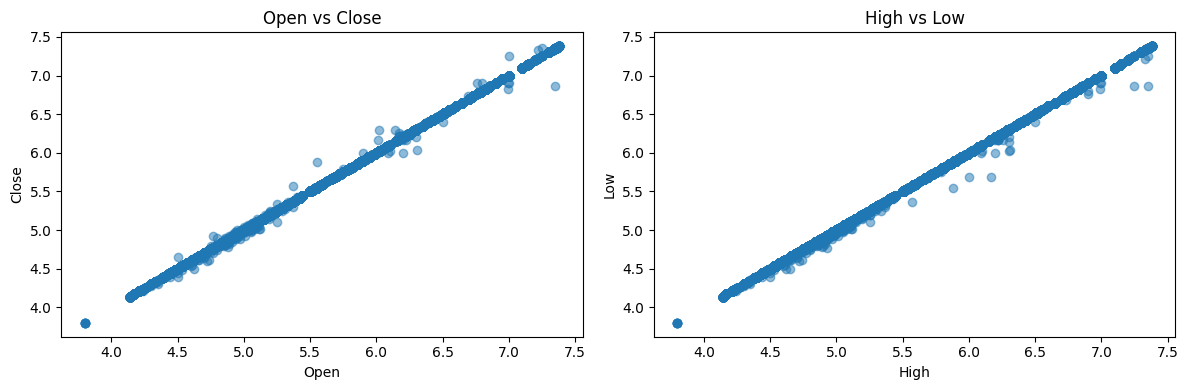


=== Model Performance ===
Accuracy: 0.9957

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39836
           1       0.00      0.00      0.00       164

    accuracy                           1.00     40000
   macro avg       0.50      0.50      0.50     40000
weighted avg       0.99      1.00      0.99     40000


✓ Model and sample data saved to output/


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Load data with cross-platform compatibility
df = pd.read_csv("btcusd_decoded_sample.csv") # Use relative path
print(df)

print("\nDataset Info:")
df.info()
print("\nFirst few rows:")
print(df.head())

# Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(df["Open"], df["Close"], alpha=0.5)
plt.xlabel("Open")
plt.ylabel("Close")
plt.title("Open vs Close")

plt.subplot(1, 2, 2)
plt.scatter(df["High"], df["Low"], alpha=0.5)
plt.xlabel("High")
plt.ylabel("Low")
plt.title("High vs Low")
plt.tight_layout()
plt.show()

# Feature Engineering
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df['returns'] = df['Close'].pct_change()
df['target'] = np.where(df['returns'].shift(-1) > 0, 1, 0)
df = df.dropna()

# Add temporal features
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.dayofweek

# Optional: Calculate actual RSI instead of placeholder
# For now, keeping as feature placeholder
df['rsi'] = 50

# Prepare features and target
X = df[['Open', 'High', 'Low', 'Close', 'Volume', 'hour', 'day']]
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print('\n=== Model Performance ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Save model and data
joblib.dump(model, output_dir / 'btc_predictor_model.pkl')
df.tail(1000).to_csv(output_dir / 'sample_data.csv', index=False)

print('\n✓ Model and sample data saved to output/')